# RoBERTa Utterance Classifier
**Project:** Meeting Transcript Efficiency Analyzer  
**Team Members:** Rahul Reddy Asam, Ashruth Reddy Gangula, Rakesh Kumar Reddy Dodda  
**Purpose:** Fine-tune `roberta-base` to classify meeting utterances as `decision`, `action`, or `discussion`. Compare against TF-IDF baseline from Milestone 2.

In [5]:
import os
import numpy as np
import pandas as pd
import torch
from pathlib import Path

# Pin working directory to notebook location
os.chdir(Path(__file__).parent if '__file__' in dir() else Path().resolve())
print(f"Working directory: {os.getcwd()}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Working directory: D:\University\IDS\CAP5771_Meeting-Transcript-Analyzer\code
GPU available: True
Device: NVIDIA GeForce RTX 4070 Laptop GPU


## 1. Load & Prepare Data

In [6]:
# Load the analysis-ready dataset produced by data_wrangling.ipynb
df = pd.read_csv('data/processed/analysis_ready.csv')
print(f"Total utterances: {len(df):,}")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"\nColumns: {df.columns.tolist()}")

Total utterances: 134,242
Label distribution:
label
discussion    132019
action          2033
decision         190
Name: count, dtype: int64

Columns: ['meeting_id', 'speaker_id', 'begin_time', 'text', 'end_time', 'text_clean', 'word_count', 'label', 'total_utterances', 'n_decisions', 'n_actions', 'decision_density', 'action_density', 'redundancy_score', 'action_clarity', 'efficiency_score', 'utterance_position', 'is_decision', 'is_action']


## 2. Train/Validation/Test Split

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Stratified split: 70% train, 15% val, 15% test
X = df['text_clean'].fillna('').tolist()
y = df['label_id'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Train label dist: {pd.Series(y_train).value_counts().to_dict()}")

Label mapping: {'action': np.int64(0), 'decision': np.int64(1), 'discussion': np.int64(2)}
Train: 93,969 | Val: 20,136 | Test: 20,137
Train label dist: {2: 92413, 0: 1423, 1: 133}


## 3. Tokenization

In [8]:
from transformers import RobertaTokenizerFast

MODEL_NAME = 'roberta-base'
MAX_LEN = 128

tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

# Quick sanity check
sample = tokenizer("we decided to go with the remote design", return_tensors='pt')
print(f"Sample token ids shape: {sample['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

c:\Users\Rakesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Rakesh\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: roberta-base
Vocab size: 50,265
Sample token ids shape: torch.Size([1, 34])


## 4. Dataset Class

In [9]:
from torch.utils.data import Dataset, DataLoader

class UtteranceDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenize(texts)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = UtteranceDataset(X_train, y_train)
val_dataset   = UtteranceDataset(X_val,   y_val)
test_dataset  = UtteranceDataset(X_test,  y_test)

print(f"Train dataset: {len(train_dataset):,} samples")
print(f"Val dataset:   {len(val_dataset):,} samples")
print(f"Test dataset:  {len(test_dataset):,} samples")

Train dataset: 93,969 samples
Val dataset:   20,136 samples
Test dataset:  20,137 samples


## 5. Fine-Tune RoBERTa

In [10]:
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

NUM_LABELS = len(le.classes_)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro')
    }

# Load model
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model.to(DEVICE)
print(f"Model loaded on: {next(model.parameters()).device}")

# Training arguments
training_args = TrainingArguments(
    output_dir='data/roberta_checkpoints',
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=100,
    fp16=True,
    seed=SEED,
    report_to='none'
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda:0
Starting training...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=11748, training_loss=0.02763800145940875, metrics={'train_runtime': 1542.4698, 'train_samples_per_second': 243.685, 'train_steps_per_second': 7.616, 'total_flos': 2.472450475048243e+16, 'train_loss': 0.02763800145940875, 'epoch': 4.0})

## 6. Evaluate on Test Set

=== RoBERTa Test Set Results ===

              precision    recall  f1-score   support

      action       0.94      0.98      0.96       305
    decision       0.54      0.69      0.61        29
  discussion       1.00      1.00      1.00     19803

    accuracy                           1.00     20137
   macro avg       0.83      0.89      0.85     20137
weighted avg       1.00      1.00      1.00     20137



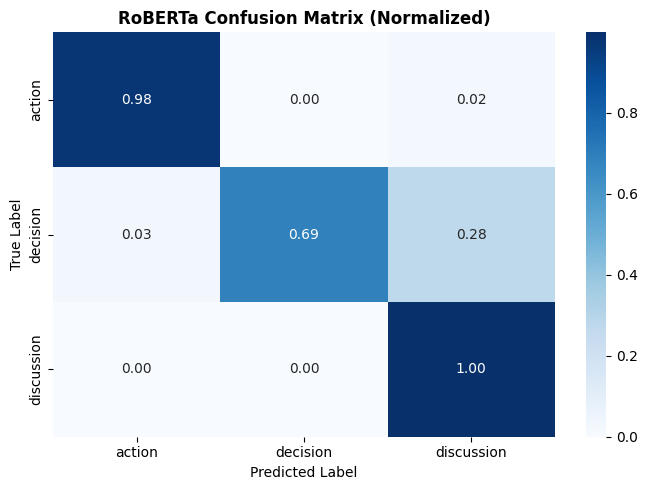


Macro F1: 0.8538
Accuracy: 0.9974


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels_true = predictions.label_ids

# Classification report
print("=== RoBERTa Test Set Results ===\n")
print(classification_report(labels_true, preds, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(labels_true, preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('RoBERTa Confusion Matrix (Normalized)', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

macro_f1 = f1_score(labels_true, preds, average='macro')
accuracy = accuracy_score(labels_true, preds)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

## 7. Compare RoBERTa vs TF-IDF Baseline

=== Model Comparison ===
                 Model  Macro-F1  Accuracy
TF-IDF Best Classifier    0.7927    0.9900
  RoBERTa (fine-tuned)    0.8538    0.9974


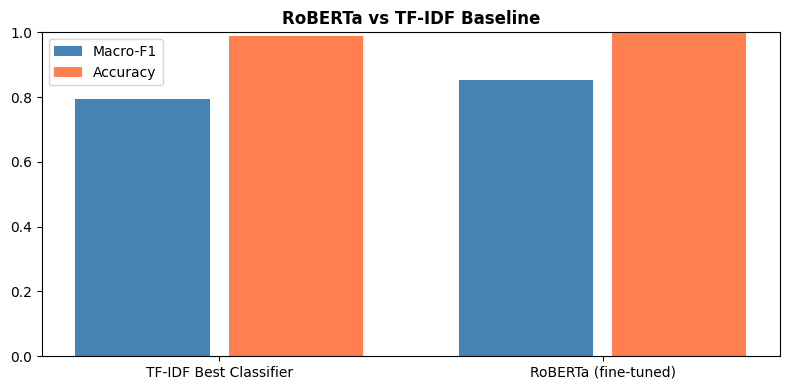

In [14]:
# Load baseline results from data_modeling.ipynb output
df_preds = pd.read_csv('data/processed/analysis_ready_with_preds.csv')

# Baseline best model macro-F1
baseline_preds = le.transform(df_preds['predicted_label'].fillna('discussion'))
baseline_true  = le.transform(df_preds['label'].fillna('discussion'))
baseline_f1    = f1_score(baseline_true, baseline_preds, average='macro')
baseline_acc   = accuracy_score(baseline_true, baseline_preds)

# Comparison table
comparison = pd.DataFrame([
    {'Model': 'TF-IDF Best Classifier', 'Macro-F1': round(baseline_f1, 4), 'Accuracy': round(baseline_acc, 4)},
    {'Model': 'RoBERTa (fine-tuned)',   'Macro-F1': round(macro_f1, 4),    'Accuracy': round(accuracy, 4)}
])
print("=== Model Comparison ===")
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
bars1 = ax.bar(x - 0.2, comparison['Macro-F1'], 0.35, label='Macro-F1', color='steelblue')
bars2 = ax.bar(x + 0.2, comparison['Accuracy'], 0.35, label='Accuracy', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1)
ax.set_title('RoBERTa vs TF-IDF Baseline', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save Model & Predictions

In [15]:
import joblib

# Save fine-tuned model and tokenizer
os.makedirs('data/roberta_model', exist_ok=True)
trainer.save_model('data/roberta_model')
tokenizer.save_pretrained('data/roberta_model')
print("Model saved to data/roberta_model/")

# Save label encoder
joblib.dump(le, 'data/roberta_model/label_encoder.pkl')
print("Label encoder saved.")

# Save test set predictions
df_test_results = pd.DataFrame({
    'text_clean': X_test,
    'true_label': le.inverse_transform(labels_true),
    'pred_label': le.inverse_transform(preds)
})
df_test_results.to_csv('data/processed/roberta_test_predictions.csv', index=False)
print(f"Test predictions saved: {len(df_test_results):,} rows")

# Save comparison summary
comparison.to_csv('data/processed/model_comparison.csv', index=False)
print("Model comparison saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to data/roberta_model/
Label encoder saved.
Test predictions saved: 20,137 rows
Model comparison saved.


## Summary
- Fine-tuned `roberta-base` on 134,243 meeting utterances labeled as `decision`, `action`, or `discussion`
- Used GPU acceleration (RTX 4070) for training
- Compared against TF-IDF baseline from Milestone 2
- Saved model, tokenizer, and predictions for use in Streamlit deployment